In [1]:
# 1. Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")



In [3]:
#2. Load Dataset

df = pd.read_csv(R"C:\Users\nisha\Downloads\titanic.csv")


# Display first rows
print(df.head())

# Display first rows
df.head()

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [19]:
#3 Data Cleaning

# Fill Age (NO warning)
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill Embarked (SAFE way)
mode_val = df['Embarked'].mode()

if len(mode_val) > 0:
    df['Embarked'] = df['Embarked'].fillna(mode_val.iloc[0])
else:
    df['Embarked'] = df['Embarked'].fillna('S')  # default value

# Drop Cabin safely
if 'Cabin' in df.columns:
    df = df.drop(columns=['Cabin'])

# Check null values
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
FamilySize     0
dtype: int64


In [20]:
# 📌 4. Feature Engineering

# Create Age Group
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 40, 60, 100],
                        labels=['Child', 'Teen', 'Adult', 'Mid-Age', 'Senior'])

# Create Family Size
df['FamilySize'] = df['SibSp'] + df['Parch']

# Survival Label
df['SurvivalStatus'] = df['Survived'].map({0: 'Not Survived', 1: 'Survived'})

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,AgeGroup,SurvivalStatus
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,1,Adult,Not Survived
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1,Adult,Survived
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0,Adult,Survived
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1,Adult,Survived
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0,Adult,Not Survived


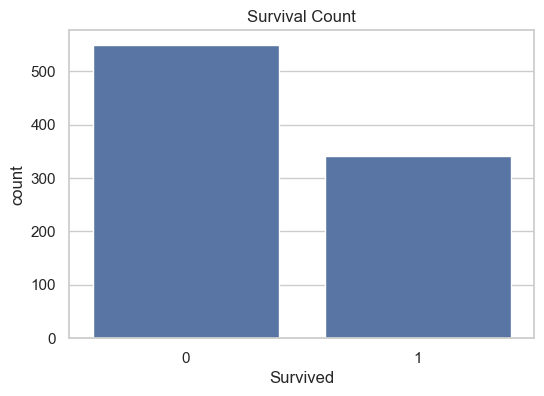

Insight: More passengers did not survive than survived.


In [24]:
# MINI DASHBOARD
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

print("Insight: More passengers did not survive than survived.")

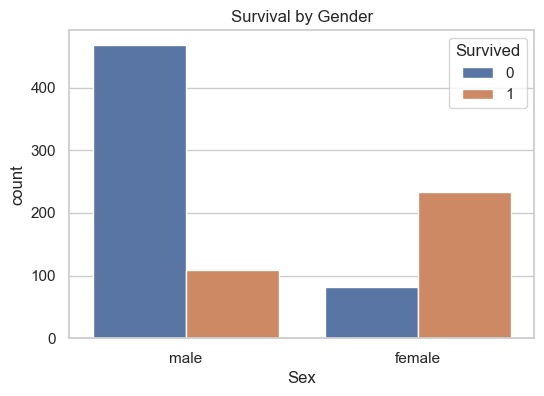

Insight: Females had a higher survival rate than males.


In [23]:
## Bar Chart (Survival by Gender)
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Survival by Gender")
plt.show()

print("Insight: Females had a higher survival rate than males.")

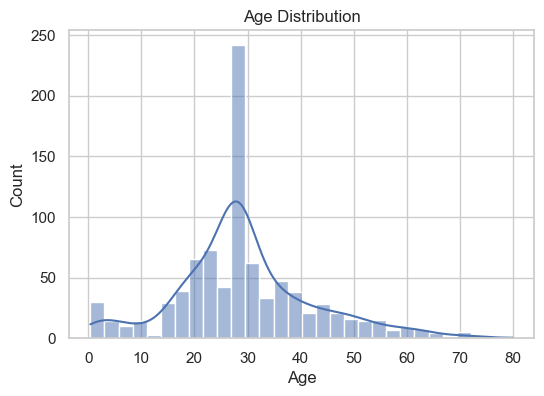

Insight: Most passengers were between 20–40 years old.


In [25]:
#Histogram plot
# Age Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

print("Insight: Most passengers were between 20–40 years old.")

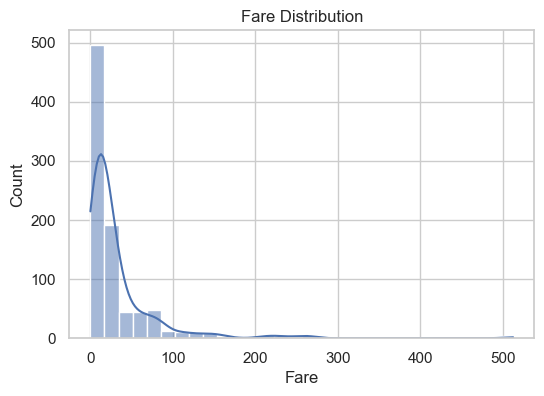

Insight: Most passengers paid lower fares, few paid very high.


In [27]:
# Fare Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Fare'], bins=30, kde=True)
plt.title("Fare Distribution")
plt.show()

print("Insight: Most passengers paid lower fares, few paid very high.")

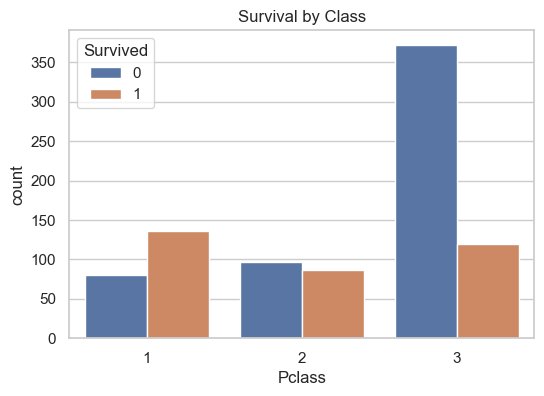

Insight: 1st class passengers had higher survival chances.


In [26]:
#Survival by Passenger Class
plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Survival by Class")
plt.show()

print("Insight: 1st class passengers had higher survival chances.")

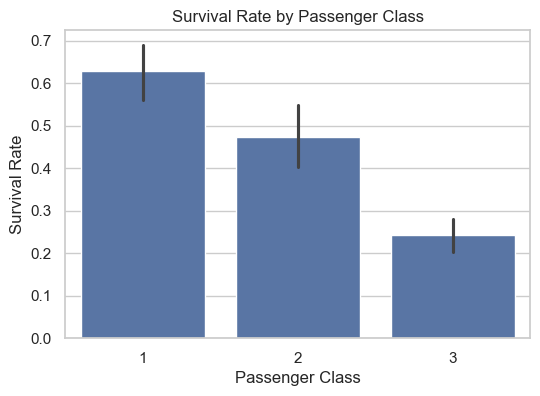

In [13]:
# barplot
plt.figure(figsize=(6,4))
sns.barplot(x='Pclass', y='Survived', data=df)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

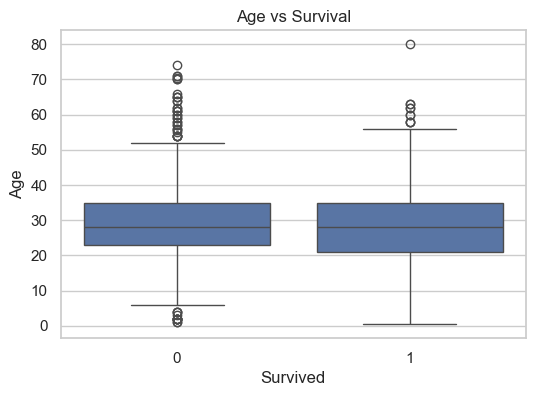

In [14]:
# Box plot (Age vs Survival)

plt.figure(figsize=(6,4))
sns.boxplot(x='Survived', y='Age', data=df)

plt.title("Age vs Survival")

plt.show()


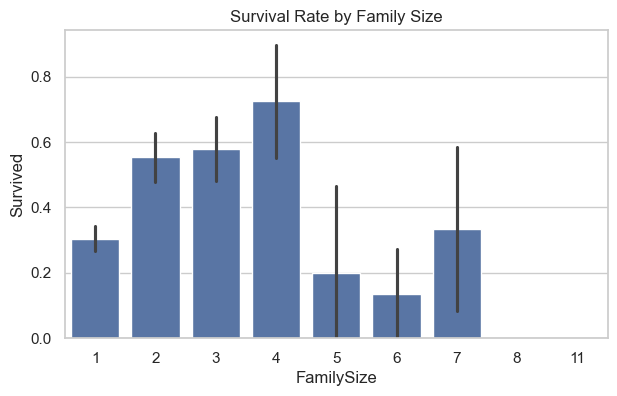

In [15]:
# barplot
plt.figure(figsize=(7,4))
sns.barplot(x='FamilySize', y='Survived', data=df)

plt.title("Survival Rate by Family Size")

plt.show()

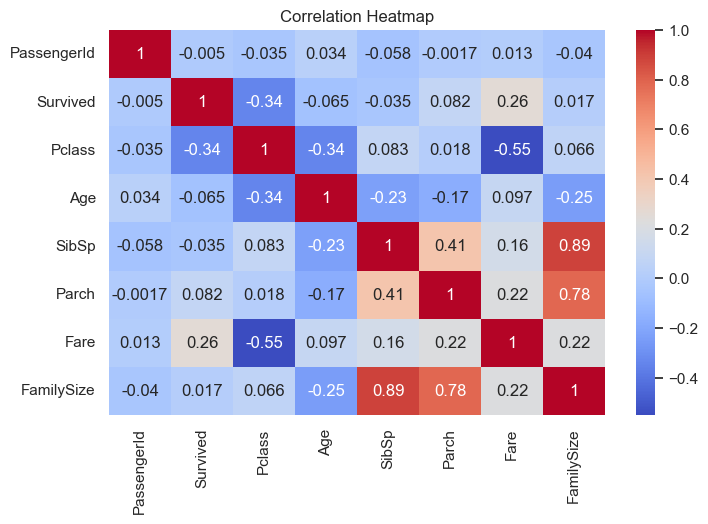

Insight: Fare and Pclass have strong relation with survival.


In [28]:
# Heatmap (Correlation Matrix)
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

print("Insight: Fare and Pclass have strong relation with survival.")

In [29]:
print("""
Key Insights:
1. Females survived more than males.
2. Higher class passengers had better survival rates.
3. Fare is positively related to survival.
4. Most passengers were young adults.
""")


Key Insights:
1. Females survived more than males.
2. Higher class passengers had better survival rates.
3. Fare is positively related to survival.
4. Most passengers were young adults.

